In [21]:
import sqlite3
import pandas as pd
import numpy as np

from pathlib import Path
DB_PATH = '../../data/hospital_typology.db'

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql('SELECT * FROM model_features', conn)
conn.close()

print(f"Shape: {df.shape}")       # expect (3056, 10)
print(f"Columns: {list(df.columns)}")
print(f"Dtypes:\n{df.dtypes}")
print(f"First 5 rows:")
df.head()

Shape: (3056, 10)
Columns: ['ccn', 'log_bed_count', 'cmi', 'is_teaching', 'safety_net_burden', 'safety_net_burden_imputed', 'is_metro', 'is_micro', 'is_small_town', 'is_rural']
Dtypes:
ccn                           object
log_bed_count                float64
cmi                          float64
is_teaching                    int64
safety_net_burden            float64
safety_net_burden_imputed      int64
is_metro                       int64
is_micro                       int64
is_small_town                  int64
is_rural                       int64
dtype: object
First 5 rows:


,ccn,log_bed_count,cmi,is_teaching,safety_net_burden,safety_net_burden_imputed,is_metro,is_micro,is_small_town,is_rural
0,010001,5.843544,1.9757,1,0.2752,0,1,0,0,0
1,010005,5.204007,1.5027,0,0.3164,0,0,1,0,0
2,010006,5.407172,1.7048,1,0.2040,0,1,0,0,0
3,010007,3.806662,1.2341,0,0.2580,0,0,0,1,0
4,010011,5.648974,1.8662,1,0.2157,0,1,0,0,0


In [22]:

FEATURE_COLS = [
    'log_bed_count',
    'cmi',
    'is_teaching',
    'safety_net_burden',
    'is_metro',
    'is_micro',
    'is_small_town',
    'is_rural',
]

X = df[FEATURE_COLS].values    # 3056 x 8 feature matrix for clustering
ccns = df['ccn'].values        # identifier for joining cluster IDs back later

print(f"X shape: {X.shape}")
print(f"Raw feature stats (pre-scaling):")
df[FEATURE_COLS].describe().round(3)

X shape: (3056, 8)
Raw feature stats (pre-scaling):


,log_bed_count,cmi,is_teaching,safety_net_burden,is_metro,is_micro,is_small_town,is_rural
count,3056.000,3056.000,3056.000,3056.000,3056.000,3056.000,3056.000,3056.000
mean,4.840,1.748,0.421,0.304,0.726,0.186,0.048,0.040
std,1.055,0.449,0.494,0.165,0.446,0.389,0.214,0.197
min,0.000,0.622,0.000,0.002,0.000,0.000,0.000,0.000
25%,4.078,1.478,0.000,0.202,0.000,0.000,0.000,0.000
50%,4.927,1.676,0.000,0.282,1.000,0.000,0.000,0.000
75%,5.599,1.932,1.000,0.368,1.000,0.000,0.000,0.000
max,7.955,4.967,1.000,1.079,1.000,1.000,1.000,1.000


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
print("Post-scaling stats (mean ≈ 0, std ≈ 1):")
print(scaled_df.describe().round(3).loc[['mean', 'std']])

# useful when scoring new hospitals later
print("Learned scaling parameters (per feature):")
print(pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean': scaler.mean_.round(3),
    'scale': scaler.scale_.round(3)
}))

Post-scaling stats (mean ≈ 0, std ≈ 1):
      log_bed_count  cmi  is_teaching  safety_net_burden  is_metro  is_micro  \
mean            0.0 -0.0         -0.0               -0.0      -0.0       0.0   
std             1.0  1.0          1.0                1.0       1.0       1.0   

      is_small_town  is_rural  
mean            0.0       0.0  
std             1.0       1.0  
Learned scaling parameters (per feature):
             feature   mean  scale
0      log_bed_count  4.840  1.055
1                cmi  1.748  0.449
2        is_teaching  0.421  0.494
3  safety_net_burden  0.304  0.165
4           is_metro  0.726  0.446
5           is_micro  0.186  0.389
6      is_small_town  0.048  0.214
7           is_rural  0.040  0.197


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 13)
results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    results.append({'k': k, 'inertia': km.inertia_, 'silhouette': sil})

results_df = pd.DataFrame(results)
print(results_df.round(4))

     k     inertia  silhouette
0    2  17372.5605      0.4142
1    3  14065.4033      0.4519
2    4  10707.8617      0.4729
3    5   7676.0233      0.4420
4    6   6194.3848      0.4643
5    7   5144.4025      0.4703
6    8   4602.6265      0.4391
7    9   4091.6365      0.4105
8   10   3697.5163      0.4011
9   11   3428.4806      0.4084
10  12   3274.5513      0.3831


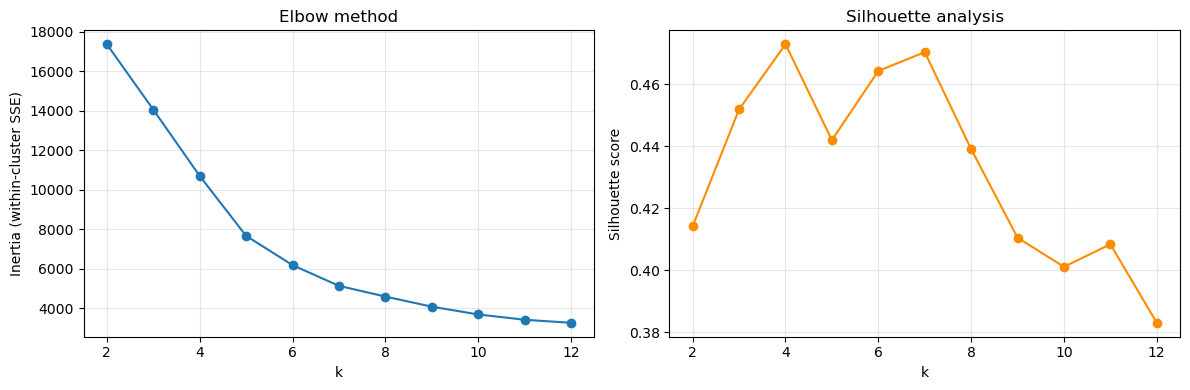

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results_df['k'], results_df['inertia'], 'o-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['k'], results_df['silhouette'], 'o-', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette analysis')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
candidates = [4, 7]
df_with_clusters = df.copy()

for k in candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_with_clusters[f'cluster_k{k}'] = km.fit_predict(X_scaled)

# Cluster sizes
for k in candidates:
    print(f"Cluster sizes for k={k}:")
    print(df_with_clusters[f'cluster_k{k}'].value_counts().sort_index())

Cluster sizes for k=4:
cluster_k4
0     147
1    2219
2     567
3     123
Name: count, dtype: int64
Cluster sizes for k=7:
cluster_k7
0    850
1    565
2    147
3    971
4    123
5    258
6    142
Name: count, dtype: int64


In [25]:
for k in candidates:
    print(f"{'='*78}")
    print(f"Cluster profiles for k={k}")
    print(f"{'='*78}")

    profile = df_with_clusters.groupby(f'cluster_k{k}')[FEATURE_COLS].mean().round(3)
    profile['n'] = df_with_clusters.groupby(f'cluster_k{k}').size()
    # Back-transform log_bed_count into approximate median bed count for readability
    profile['~beds'] = np.exp(profile['log_bed_count']).round(0).astype(int)

    cols = ['n', '~beds'] + FEATURE_COLS
    print(profile[cols].to_string())

Cluster profiles for k=4
               n  ~beds  log_bed_count    cmi  is_teaching  safety_net_burden  is_metro  is_micro  is_small_town  is_rural
cluster_k4                                                                                                                
0            147     43          3.750  1.362        0.082              0.293       0.0       0.0            1.0       0.0
1           2219    167          5.116  1.862        0.520              0.307       1.0       0.0            0.0       0.0
2            567     73          4.294  1.514        0.192              0.294       0.0       1.0            0.0       0.0
3            123     39          3.670  1.234        0.098              0.299       0.0       0.0            0.0       1.0
Cluster profiles for k=7
              n  ~beds  log_bed_count    cmi  is_teaching  safety_net_burden  is_metro  is_micro  is_small_town  is_rural
cluster_k7                                                                                

In [26]:
final_k = 7
km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_ids = km_final.fit_predict(X_scaled)

clusters_df = pd.DataFrame({
    'ccn': df['ccn'],
    'cluster_id': cluster_ids
})

print(f"Cluster assignments: {len(clusters_df)} hospitals across {final_k} clusters")
print(clusters_df['cluster_id'].value_counts().sort_index())

conn = sqlite3.connect(DB_PATH)
clusters_df.to_sql('model_hospital_clusters', conn, if_exists='replace', index=False)
conn.close()

print(f"Wrote model_hospital_clusters ({len(clusters_df)} rows) to {DB_PATH}")

Cluster assignments: 3056 hospitals across 7 clusters
cluster_id
0    850
1    565
2    147
3    971
4    123
5    258
6    142
Name: count, dtype: int64
Wrote model_hospital_clusters (3056 rows) to ../../data/hospital_typology.db
